# 2 The Solow model with a time-varying savings rate

In [29]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.optimize import root_scalar
from scipy.optimize import minimize

### 2.1 Question 1

#### 2.1.1 Steady state
Using the analytical formulas with $s=\bar{s}=0.25$, the steady-state values are:

- $k^*=0.760726$
- $y^*=0.912871$
- $c^*=0.684653$

The root finder confirms the same steady-state capital:

- $k^*=0.760726$

#### 2.1.2 Baseline simulation
The model is simulated for 100 periods with a constant savings rate of $s_t=0.25$.

The reported values are:

- $c_0=0.348119$
- $c_{T-1}=0.684653$
- $k_{T-1}=0.760726$

#### 2.1.3 Simulator test
The simulator passes both tests:

- An economy starting at $k^*$ remains at the steady state.
- With $s_t=0$, capital follows $k_t=(1-\delta)^t k_0$.


k* = 0.760726
y* = 0.912871
c* = 0.684653
k* (root finder) = 0.760726


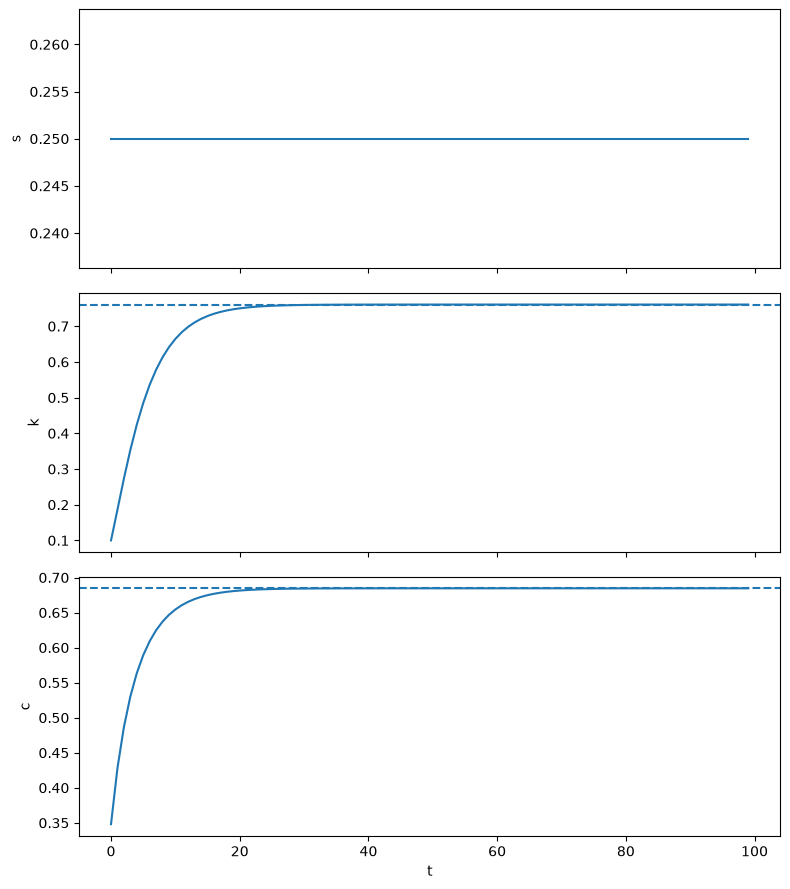

c0 = 0.348119
c(T-1) = 0.684653
k(T-1) = 0.760726
all tests passed


In [30]:
# 2.1.1 Parameters and analytical steady state
alpha = 1/3
delta = 0.30
s_bar = 0.25
beta = 1/1.2
T = 100
k0 = 0.10

# Steady state (analytical)
k_star = (s_bar / delta) ** (1 / (1 - alpha))
y_star = k_star ** alpha
c_star = (1 - s_bar) * y_star

print(f"k* = {k_star:.6f}")
print(f"y* = {y_star:.6f}")
print(f"c* = {c_star:.6f}")

# 2.1.1 Numerical steady state using a root finder
def steady_state_eq(k):
    return s_bar * k**alpha + (1 - delta) * k - k

sol = root_scalar(steady_state_eq, bracket=[1e-8, 100], method="brentq")
print(f"k* (root finder) = {sol.root:.6f}")

# 2.1.2-2.1.3 Common simulator and baseline
# The same simulator accepts a constant or a time-varying savings rate.
def simulate_solow(k0, s, alpha, delta, T):
    s_path = np.full(T, s) if np.ndim(s) == 0 else np.asarray(s, dtype=float)
    assert s_path.size == T, f"the savings rate must have {T} elements"

    k = np.empty(T)
    y = np.empty(T)
    c = np.empty(T)

    k[0] = k0
    for t in range(T):
        y[t] = k[t] ** alpha
        c[t] = (1 - s_path[t]) * y[t]
        if t < T - 1:
            k[t + 1] = s_path[t] * y[t] + (1 - delta) * k[t]

    return k, y, c, s_path

# 2.1.2 Baseline simulation and figure
k, y, c, s_path = simulate_solow(k0, s_bar, alpha, delta, T)

# Figure
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(s_path)
ax[0].set_ylabel("s")
ax[1].plot(k)
ax[1].axhline(k_star, ls="--")
ax[1].set_ylabel("k")
ax[2].plot(c)
ax[2].axhline(c_star, ls="--")
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")
plt.tight_layout()
plt.show()

print(f"c0 = {c[0]:.6f}")
print(f"c(T-1) = {c[-1]:.6f}")
print(f"k(T-1) = {k[-1]:.6f}")

# 2.1.3 Tests, following the lecture's test() pattern
def test_simulator():
    k_test, _, _, _ = simulate_solow(k_star, s_bar, alpha, delta, 20)
    assert np.allclose(k_test, k_star)

    k_decay, _, _, _ = simulate_solow(k0, 0.0, alpha, delta, 20)
    assert np.allclose(k_decay, k0 * (1 - delta) ** np.arange(20))

    print("all tests passed")


test_simulator()


### 2.2 Question 2
#### 2.2.1-2 Time-varying savings rule and simulations
The savings rule was implemented as

$$
s_t=\bar{s}+(s_0-\bar{s})\phi^t
$$

and the model was simulated for all four parameter combinations together with the baseline.

#### 2.2.3 Final capital
| Case | $k_{T-1}$ |
|---|---:|
| Baseline | 0.760726 |
| $s_0=0.30,\ \phi=0.50$ | 0.760726 |
| $s_0=0.40,\ \phi=0.80$ | 0.760726 |
| $s_0=0.10,\ \phi=0.50$ | 0.760726 |
| $s_0=0.60,\ \phi=0.60$ | 0.760726 |

All five cases have the same final capital when rounded to six decimal places. They are not exactly identical at $T=100$, because the time-varying savings rates approach $\bar{s}$ gradually; the numerical differences are only around $10^{-9}$.

#### 2.2.4 Interpretation
- A higher $s_0$ increases savings in the first periods, while a lower $s_0$ reduces initial savings. Consequently, a higher $s_0$ gives lower consumption initially, but leads to higher capital, output and consumption in later periods.
- A higher $\phi$ makes the savings rate return more slowly toward $\bar{s}$, while a lower $\phi$ makes it return more quickly. Thus, a high $\phi$ prolongs the initial consumption-investment trade-off, whereas a low $\phi$ makes the effects of $s_0$ disappear faster.


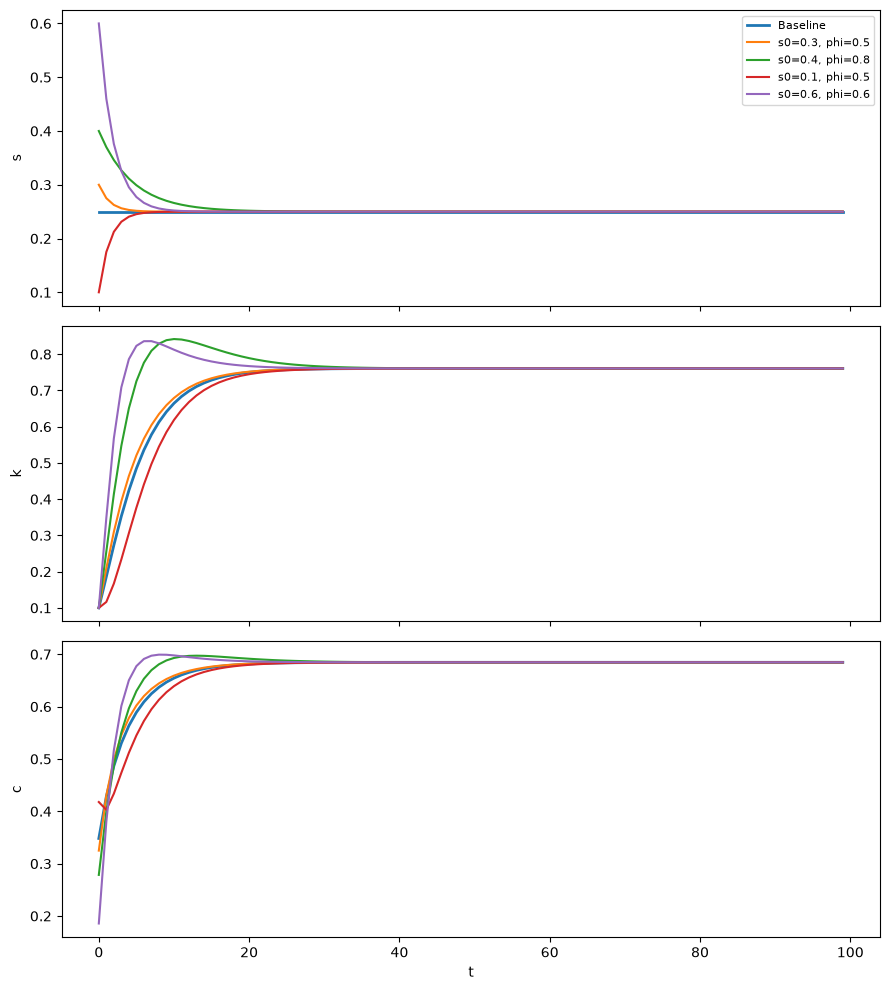

Baseline: k(T-1) = 0.760726
s0=0.3, phi=0.5: k(T-1) = 0.760726
s0=0.4, phi=0.8: k(T-1) = 0.760726
s0=0.1, phi=0.5: k(T-1) = 0.760726
s0=0.6, phi=0.6: k(T-1) = 0.760726


In [31]:
# 2.2.1 Savings rule
def savings_rule(s0, phi, s_bar, T):
    t = np.arange(T)
    return s_bar + (s0 - s_bar) * phi**t

# 2.2.2 Simulate the four cases and compare them with the baseline
baseline = {"k": k, "y": y, "c": c, "s": s_path}

# Four combinations
cases = [
    (0.30, 0.50),
    (0.40, 0.80),
    (0.10, 0.50),
    (0.60, 0.60),
]

results = {}

# Simulate all cases using the common simulator
for s0, phi in cases:
    s_i = savings_rule(s0, phi, s_bar, T)
    k_i, y_i, c_i, s_i = simulate_solow(
        k0, s_i, alpha, delta, T
    )
    results[(s0, phi)] = {
        "k": k_i,
        "y": y_i,
        "c": c_i,
        "s": s_i,
    }

# 2.2.2 Figure
fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

# Savings rate
ax[0].plot(baseline["s"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[0].plot(res["s"], label=f"s0={s0}, phi={phi}")
ax[0].set_ylabel("s")
ax[0].legend(fontsize=8)

# Capital
ax[1].plot(baseline["k"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[1].plot(res["k"], label=f"s0={s0}, phi={phi}")
ax[1].set_ylabel("k")

# Consumption
ax[2].plot(baseline["c"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[2].plot(res["c"], label=f"s0={s0}, phi={phi}")
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()

# 2.2.3 Report final capital
print(f"Baseline: k(T-1) = {baseline['k'][-1]:.6f}")
for (s0, phi), res in results.items():
    print(f"s0={s0}, phi={phi}: k(T-1) = {res['k'][-1]:.6f}")


### 2.3 Question 3
#### 2.3.1–2 Welfare results

| Case | $W$ | $W-W_{\text{baseline}}$ |
|---|---:|---:|
| Baseline | -3.9944 | 0.0000 |
| $s_0=0.30,\ \phi=0.50$ | -3.9857 | 0.0087 |
| $s_0=0.40,\ \phi=0.80$ | -4.0914 | -0.0970 |
| $s_0=0.10,\ \phi=0.50$ | -4.1460 | -0.1516 |
| $s_0=0.60,\ \phi=0.60$ | -4.3407 | -0.3463 |

#### 2.3.3 Comparison

Only the combination $s_0=0.30,\ \phi=0.50$ gives higher welfare than the baseline.

The figure alone does not clearly identify which combination gives the highest welfare, because welfare depends on discounted consumption over the entire path rather than only on the visual appearance of the curves.


In [32]:
# 2.3.1 Welfare function
def welfare(c, beta):
    t = np.arange(len(c))
    return np.sum(beta**t * np.log(c))

# 2.3.2 Compute and report welfare
W_baseline = welfare(baseline["c"], beta)

print(f"{'Case':<20}{'W':>12}{'Delta W':>12}")
print("-"*44)
print(f"{'Baseline':<20}{W_baseline:>12.4f}{0:>12.4f}")

for (s0, phi), res in results.items():
    W = welfare(res["c"], beta)
    print(f"s0={s0}, phi={phi:<6}{W:>12.4f}{W-W_baseline:>12.4f}")


Case                           W     Delta W
--------------------------------------------
Baseline                 -3.9944      0.0000
s0=0.3, phi=0.5        -3.9857      0.0087
s0=0.4, phi=0.8        -4.0914     -0.0970
s0=0.1, phi=0.5        -4.1460     -0.1516
s0=0.6, phi=0.6        -4.3407     -0.3463


### 2.4 Question 4

#### 2.4.1 Grid search
The best grid point is:

- $s_0=0.310$
- $\phi=0.230$
- $W=-3.9843$

#### 2.4.2 Numerical optimization
The optimizer finds:

- $s_0=0.3113$
- $\phi=0.2300$
- $W=-3.9843$

The optimized solution is almost identical to the best grid point.

#### 2.4.3 Best rule compared with the baseline
The optimized rule gives:

- $c_0=0.319658$

Consumption exceeds the baseline for the first time in period 1.


Best grid point
s0 = 0.310
phi = 0.230
W = -3.9843


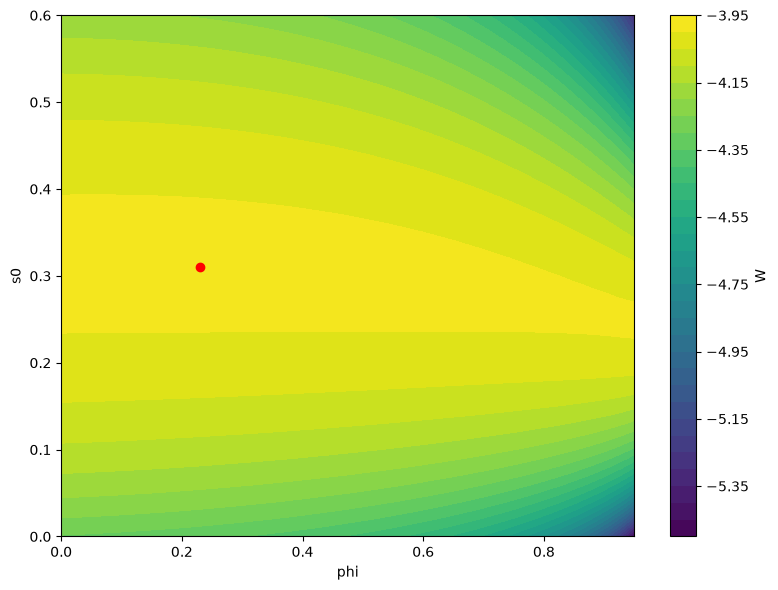


Optimized solution
s0 = 0.3113
phi = 0.2300
W = -3.9843


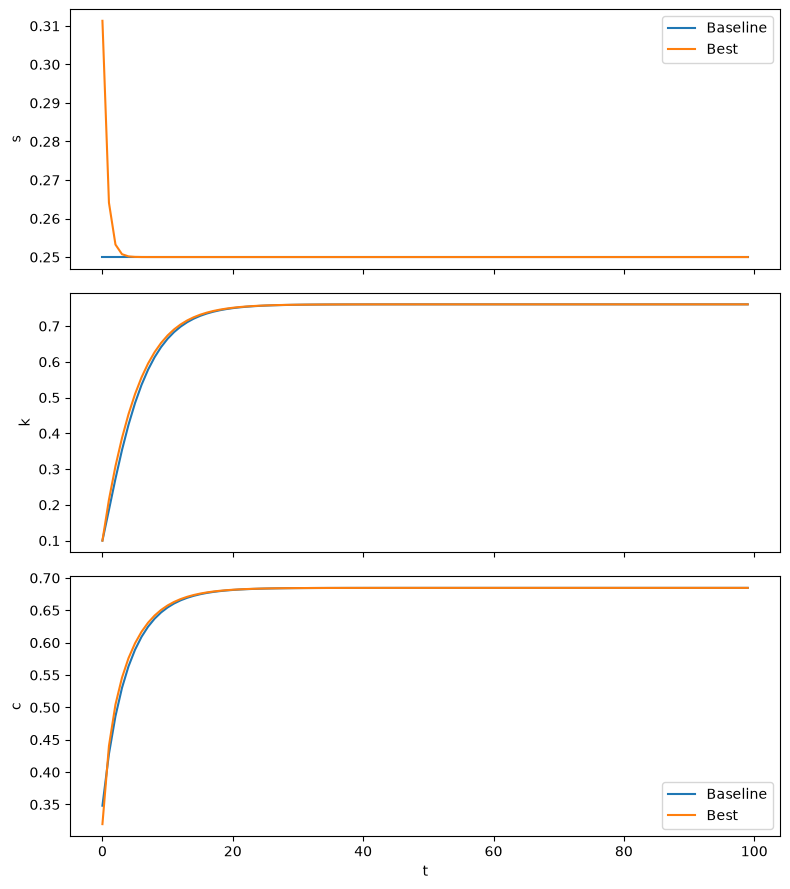

c0 = 0.319658
First period with c above baseline: 1


In [33]:
# 2.4.1 Grid search over s0 and phi
s0_grid = np.linspace(0, 0.60, 61)
phi_grid = np.linspace(0, 0.95, 96)

W_grid = np.empty((len(s0_grid), len(phi_grid)))

for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        s_i = savings_rule(s0, phi, s_bar, T)
        _, _, c_i, _ = simulate_solow(
            k0, s_i, alpha, delta, T
        )
        W_grid[i, j] = welfare(c_i, beta)

best_idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
best_s0 = s0_grid[best_idx[0]]
best_phi = phi_grid[best_idx[1]]
best_W = W_grid[best_idx]

print("Best grid point")
print(f"s0 = {best_s0:.3f}")
print(f"phi = {best_phi:.3f}")
print(f"W = {best_W:.4f}")

# 2.4.1 Contour plot of welfare on the grid
plt.figure(figsize=(8,6))
plt.contourf(phi_grid, s0_grid, W_grid, levels=30)
plt.colorbar(label="W")
plt.scatter(best_phi, best_s0, color="red")
plt.xlabel("phi")
plt.ylabel("s0")
plt.tight_layout()
plt.show()


# 2.4.2 Numerical optimization starting from the best grid point
def objective(x):
    s0, phi = x
    s_i = savings_rule(s0, phi, s_bar, T)
    _, _, c_i, _ = simulate_solow(k0, s_i, alpha, delta, T)
    return -welfare(c_i, beta)

opt = minimize(
    objective,
    x0=[best_s0, best_phi],
    method="SLSQP",
    bounds=[(0, 0.60), (0, 0.95)],
)

assert opt.success, opt.message

opt_s0, opt_phi = opt.x
opt_W = -opt.fun

print("\nOptimized solution")
print(f"s0 = {opt_s0:.4f}")
print(f"phi = {opt_phi:.4f}")
print(f"W = {opt_W:.4f}")


# 2.4.3 Plot the optimized rule against the baseline
s_opt = savings_rule(opt_s0, opt_phi, s_bar, T)
k_opt, y_opt, c_opt, s_opt = simulate_solow(
    k0, s_opt, alpha, delta, T
)

fig, ax = plt.subplots(3,1,figsize=(8,9),sharex=True)
ax[0].plot(baseline["s"], label="Baseline")
ax[0].plot(s_opt, label="Best")
ax[0].legend()
ax[0].set_ylabel("s")
ax[1].plot(baseline["k"])
ax[1].plot(k_opt)
ax[1].set_ylabel("k")
ax[2].plot(baseline["c"], label="Baseline")
ax[2].plot(c_opt, label="Best")
ax[2].legend()
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")
plt.tight_layout()
plt.show()

# First period where consumption exceeds baseline
above = np.where(c_opt > baseline["c"])[0]
first_above = above[0] if len(above) > 0 else None

print(f"c0 = {c_opt[0]:.6f}")
print(f"First period with c above baseline: {first_above}")


### 2.5 Question 5

#### 2.5.1 Three-parameter optimization

The optimal parameters are:

- $s_0=0.3139$
- $\phi=0.6704$
- $s_\infty=0.1990$

The resulting welfare is:

- $W=-3.9670$

This improves welfare by 0.0173 compared with Question 2.4.

#### 2.5.2 Final capital

- $k_{T-1}=0.540089$
- Old steady state from Question 2.1: $k^*=0.760726$

Because the long-run savings rate is now $s_\infty=0.1990$, the relevant long-run steady state is instead

$$
k_\infty^*=\left(\frac{s_\infty}{\delta}\right)^{1/(1-\alpha)}
=\left(\frac{0.1990}{0.30}\right)^{1/(1-1/3)}
\approx0.5401.
$$

Thus, $k_{T-1}$ is not equal to the old steady state from Question 2.1, and it should not be. Since the long-run savings rate has changed, the economy converges toward the new steady state $k_\infty^*\approx0.5401$. The simulated value $k_{T-1}=0.540089$ lies very close to this new steady state.


In [34]:
# 2.5.1 Three-parameter savings rule and numerical optimization
def savings_rule_three(s0, phi, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) * phi**t


def objective3(x):
    s0, phi, s_inf = x
    s_i = savings_rule_three(s0, phi, s_inf, T)
    _, _, c_i, _ = simulate_solow(k0, s_i, alpha, delta, T)
    return -welfare(c_i, beta)


opt3 = minimize(
    objective3,
    x0=[opt_s0, opt_phi, s_bar],
    method="SLSQP",
    bounds=[(0, 1), (0, 0.999), (0, 1)],
)

assert opt3.success, opt3.message

s0_best, phi_best, s_inf_best = opt3.x
W_best3 = -opt3.fun

# 2.5.2 Simulate the best three-parameter rule
s3 = savings_rule_three(s0_best, phi_best, s_inf_best, T)
k3, y3, c3, s3 = simulate_solow(
    k0, s3, alpha, delta, T
)

print(f"s0 = {s0_best:.4f}")
print(f"phi = {phi_best:.4f}")
print(f"s_inf = {s_inf_best:.4f}")
print(f"W = {W_best3:.4f}")
print(f"Improvement over Q2.4 = {W_best3-opt_W:.4f}")
print(f"k(T-1) = {k3[-1]:.6f}")
print(f"k* = {k_star:.6f}")


s0 = 0.3139
phi = 0.6704
s_inf = 0.1990
W = -3.9670
Improvement over Q2.4 = 0.0173
k(T-1) = 0.540089
k* = 0.760726


### 2.6 Question 6

#### 2.6.1-2 Alternative savings rule

As an alternative to the exponential rule, I use a hyperbolic rule:

$$
s_t=s_\infty+\frac{s_0-s_\infty}{1+\rho t}.
$$

This converges to the constant long-run level $s_\infty$, so the economy still converges toward a steady state. After numerical optimization, the parameters are:

- $s_0=0.3156$
- $\rho=0.4945$
- $s_\infty=0.1795$

The resulting welfare is:

- $W=-3.9672$

#### 2.6.3 Welfare comparison

| Rule | $W$ |
|---|---:|
| Baseline | -3.9944 |
| Best Q2.4 | -3.9843 |
| Best Q2.5 | -3.9670 |
| Alternative | -3.9672 |

The alternative rule does not outperform the three-parameter rule from Question 2.5, but it comes very close.


In [35]:
# 2.6.1 Alternative savings rule
def savings_rule_alternative(s0, rho, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) / (1 + rho * t)


# 2.6.2 Optimize welfare under the alternative rule
def objective_alternative(x):
    s0, rho, s_inf = x
    s_i = savings_rule_alternative(s0, rho, s_inf, T)
    _, _, c_i, _ = simulate_solow(k0, s_i, alpha, delta, T)
    return -welfare(c_i, beta)


opt_alternative = minimize(
    objective_alternative,
    x0=[s0_best, 1.0, s_inf_best],
    method="SLSQP",
    bounds=[(0, 0.60), (0, 10.0), (0, 0.60)],
)

assert opt_alternative.success, opt_alternative.message

s0_alternative, rho_alternative, s_inf_alternative = opt_alternative.x
W_alternative = -opt_alternative.fun

print(f"s0 = {s0_alternative:.4f}")
print(f"rho = {rho_alternative:.4f}")
print(f"s_inf = {s_inf_alternative:.4f}")
print(f"W = {W_alternative:.4f}")

# 2.6.3 Compare welfare across the rules
print("\nSummary")
print(f"{'Rule':<20}{'W':>12}")
print("-"*32)
print(f"{'Baseline':<20}{W_baseline:>12.4f}")
print(f"{'Best Q2.4':<20}{opt_W:>12.4f}")
print(f"{'Best Q2.5':<20}{W_best3:>12.4f}")
print(f"{'Alternative':<20}{W_alternative:>12.4f}")


s0 = 0.3156
rho = 0.4945
s_inf = 0.1795
W = -3.9672

Summary
Rule                           W
--------------------------------
Baseline                 -3.9944
Best Q2.4                -3.9843
Best Q2.5                -3.9670
Alternative              -3.9672
